# Predicting Marathon Finish Times for Early Talent Identification in East African Athletics

## Mission & Problem
East Africa produces the world's best distance runners, yet talent identification remains informal and often happens too late in an athlete's development. This project builds a regression model that predicts a runner's marathon finish time from their profile and early-race split times, giving coaches and athletics federations a data-driven tool to spot promising endurance athletes earlier.

## Dataset
**Source:** Finishers Boston Marathon 2015–2017 (Kaggle, user *rojour*, scraped from official B.A.A. results).
**Size:** 79,638 finishers, 27 columns age, gender, country, checkpoint splits (5K–40K) and official finish time.
**Target variable:** `Official Time` (converted to minutes).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("data/boston_marathon_2015_2017.csv", low_memory=False)
print(f"Shape: {df.shape}")
df.head()

Shape: (79638, 27)


,Unnamed: 0,Bib,Name,Age,M/F,City,State,Country,Citizen,Unnamed: 9,...,35K,40K,Pace,Proj Time,Official Time,Overall,Gender,Division,Year,Unnamed: 8
0,0.0,3,"Desisa, Lelisa",25,M,Ambo,NaN,ETH,NaN,NaN,...,1:47:59,2:02:39,0:04:56,-,2:09:17,1,1,1,2015,NaN
1,1.0,4,"Tsegay, Yemane Adhane",30,M,Addis Ababa,NaN,ETH,NaN,NaN,...,1:47:59,2:02:42,0:04:58,-,2:09:48,2,2,2,2015,NaN
2,2.0,8,"Chebet, Wilson",29,M,Marakwet,NaN,KEN,NaN,NaN,...,1:47:59,2:03:01,0:04:59,-,2:10:22,3,3,3,2015,NaN
3,3.0,11,"Kipyego, Bernard",28,M,Eldoret,NaN,KEN,NaN,NaN,...,1:48:03,2:03:47,0:05:00,-,2:10:47,4,4,4,2015,NaN
4,4.0,10,"Korir, Wesley",32,M,Kitale,NaN,KEN,NaN,NaN,...,1:47:59,2:03:27,0:05:00,-,2:10:49,5,5,5,2015,NaN


## 1. Data Cleaning & Conversion to Numeric

Split times and the finish time are stored as `H:MM:SS` text strings, which a model cannot use directly, they must be converted to numeric values (total minutes). Gender (`M/F`) is categorical and is encoded as 1/0.

In [3]:
def time_to_minutes(t):
    """Convert an 'H:MM:SS' string to total minutes. Invalid values (e.g. '-') become NaN."""
    try:
        h, m, s = str(t).split(":")
        return int(h) * 60 + int(m) + int(s) / 60
    except (ValueError, AttributeError):
        return np.nan

time_cols = ["5K", "10K", "15K", "20K", "Half", "25K", "30K", "35K", "40K", "Official Time"]
for col in time_cols:
    new_name = "Finish_min" if col == "Official Time" else f"{col}_min"
    df[new_name] = df[col].apply(time_to_minutes)

# Encode gender: Male = 1, Female = 0
df["Gender_encoded"] = (df["M/F"] == "M").astype(int)

df[["Age", "M/F", "Gender_encoded", "5K_min", "Half_min", "Finish_min"]].head()

,Age,M/F,Gender_encoded,5K_min,Half_min,Finish_min
0,25,M,1,14.716667,64.033333,129.283333
1,30,M,1,14.716667,64.016667,129.800000
2,29,M,1,14.716667,64.033333,130.366667
3,28,M,1,14.716667,64.033333,130.783333
4,32,M,1,14.716667,64.016667,130.816667


## 2. Visualizations & Interpretation

### 2.1 Correlation Heatmap

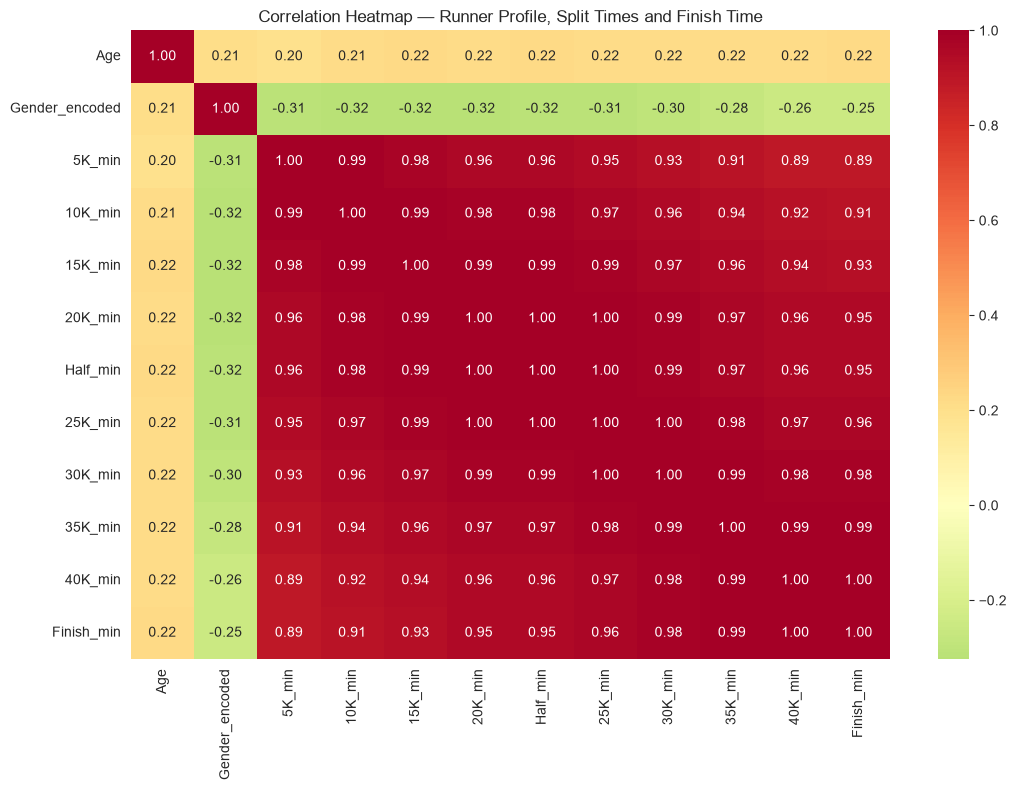

In [4]:
numeric_cols = ["Age", "Gender_encoded", "5K_min", "10K_min", "15K_min", "20K_min",
                "Half_min", "25K_min", "30K_min", "35K_min", "40K_min", "Finish_min"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0)
plt.title("Correlation Heatmap — Runner Profile, Split Times and Finish Time")
plt.tight_layout()
plt.show()

**Interpretation:**
- Split times are strongly positively correlated with the finish time, and the correlation grows the deeper into the race the split is taken (5K ≈ 0.89 → 40K ≈ 0.99). The pace→finish relationship is close to linear, confirming this problem suits linear regression.
- Age has a weak positive correlation with finish time and gender a moderate one — both are kept as features, but they carry far less weight than split times.
- Late splits (25K–40K) correlate almost perfectly (≥ 0.98) with the finish. Using them would make prediction trivial and defeat the mission: a coach needs a projection early in the race, not at kilometre 40. They will be dropped in feature engineering.

### 2.2 Distribution of the Target and Key Features

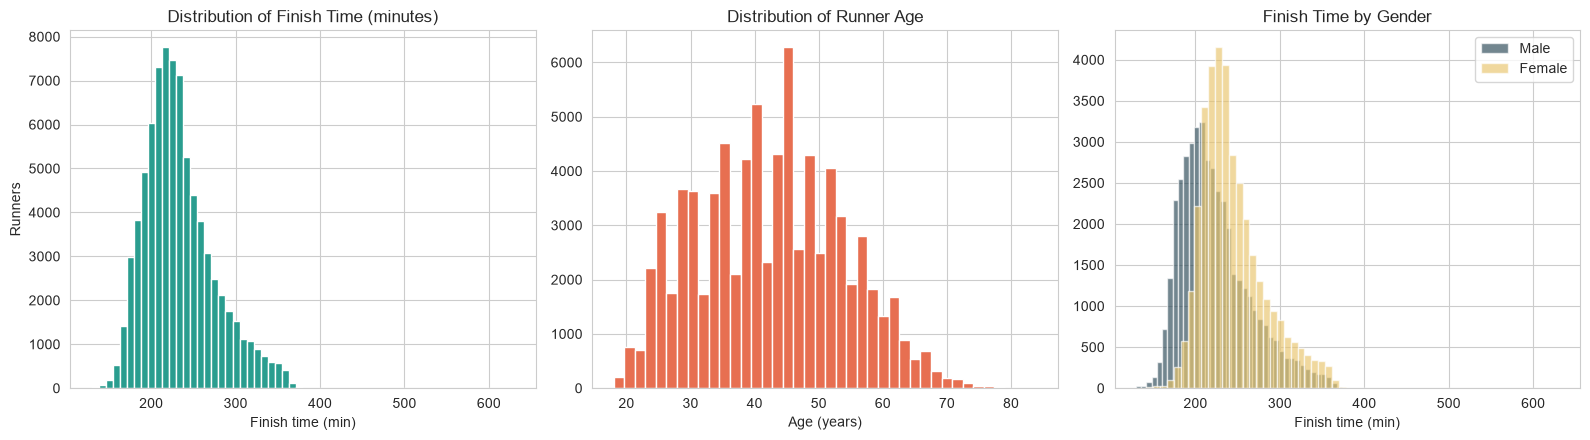

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(df["Finish_min"].dropna(), bins=60, color="#2a9d8f", edgecolor="white")
axes[0].set_title("Distribution of Finish Time (minutes)")
axes[0].set_xlabel("Finish time (min)")
axes[0].set_ylabel("Runners")

axes[1].hist(df["Age"].dropna(), bins=40, color="#e76f51", edgecolor="white")
axes[1].set_title("Distribution of Runner Age")
axes[1].set_xlabel("Age (years)")

for gender_value, label, color in [(1, "Male", "#264653"), (0, "Female", "#e9c46a")]:
    axes[2].hist(df.loc[df["Gender_encoded"] == gender_value, "Finish_min"].dropna(),
                 bins=60, alpha=0.65, label=label, color=color)
axes[2].set_title("Finish Time by Gender")
axes[2].set_xlabel("Finish time (min)")
axes[2].legend()

plt.tight_layout()
plt.show()

**Interpretation:**
- Finish times are right-skewed around a ~230-minute peak: most runners cluster together with a long tail of slower finishers. Standardization will help gradient descent converge on features with such different ranges.
- Age spans roughly 18–80 with most runners between 25 and 55 good variety for learning the age effect.
- The gender distributions overlap heavily but the male distribution is shifted left (faster on average), justifying gender as a feature.

### 2.3 Early Split vs Finish Time (the core relationship)

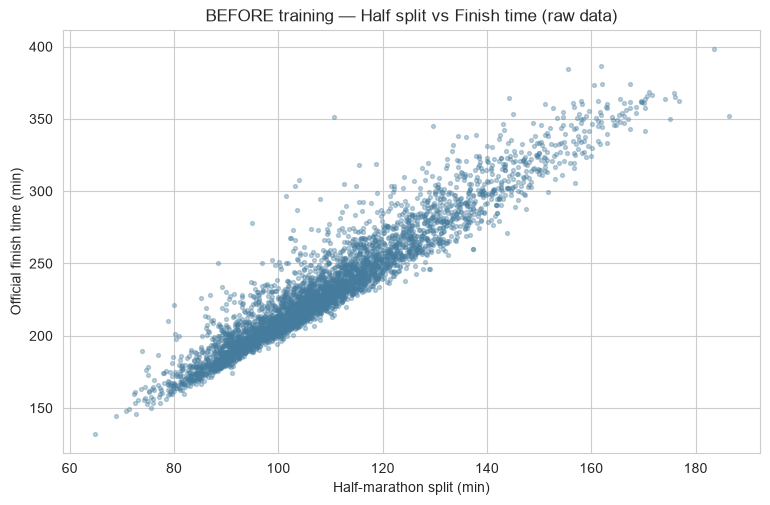

In [6]:
sample = df.dropna(subset=["Half_min", "Finish_min"]).sample(4000, random_state=RANDOM_STATE)

plt.figure(figsize=(9, 5.5))
plt.scatter(sample["Half_min"], sample["Finish_min"], s=8, alpha=0.35, color="#457b9d")
plt.xlabel("Half-marathon split (min)")
plt.ylabel("Official finish time (min)")
plt.title("BEFORE training — Half split vs Finish time (raw data)")
plt.show()

**Interpretation:**
 
the half-marathon split alone already forms a tight, visibly linear band with the finish time strong evidence a linear model will fit well. The vertical spread (same half split, different finishes) is the "second-half fade" that age, gender and earlier splits help the model explain. This is the "before" view; after training, the fitted line will be drawn through this same relationship.

## 3. Feature Engineering

**Columns dropped, and why:**

| Dropped column(s) | Reason |
|---|---|
| `Bib`, `Name`, `City`, `State`, `Country`, `Citizen`, `Unnamed` columns | Identifiers and free text with no causal link to performance; `Country` is excluded so the model learns performance, not nationality. |
| `Pace`, `Proj Time` | Direct leakage — pace is mathematically derived from the finish time itself. |
| `Overall`, `Gender`, `Division` (rank columns) | Leakage — final rankings are computed from the finish time. |
| `25K`–`40K` splits | Correlate ≥ 0.98 with the target (see heatmap), making prediction trivial and useless for early-race talent projection. |

**Features kept and their weight:** the heatmap ranks importance clearly: split times ≫ gender > age. We keep `Age`, `Gender_encoded` and the first-half splits (`5K`, `10K`, `15K`, `20K`, `Half`) — 7 features, all obtainable by a coach with a stopwatch by the halfway point.

In [9]:
FEATURES = ["Age", "Gender_encoded", "5K_min", "10K_min", "15K_min", "20K_min", "Half_min"]
TARGET = "Finish_min"

model_data = df[FEATURES + [TARGET]].dropna()
print(f"Usable rows after dropping missing values: {len(model_data):,}")

X = model_data[FEATURES]
y = model_data[TARGET]

Usable rows after dropping missing values: 79,224


## 4. Train/Test Split & Standardization

Features live on very different scales (Age ≈ 18–80, Half split ≈ 60–240 min). Gradient descent is scale-sensitive, so features are standardized to zero mean and unit variance. The scaler is fitted on the training set only, to avoid information leaking from the test set.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (63379, 7), Test: (15845, 7)


## 5. Models — SGD Linear Regression vs Three Other Implementations

Four regression implementations are compared, all with scikit-learn:
1. **`SGDRegressor`** — linear regression optimized with stochastic gradient descent
2. **`LinearRegression`** — a second linear regression implementation (closed-form OLS)
3. **`DecisionTreeRegressor`** — a tree algorithm
4. **`RandomForestRegressor`** — an ensemble algorithm

### 5.1 Gradient-descent linear regression with loss curves

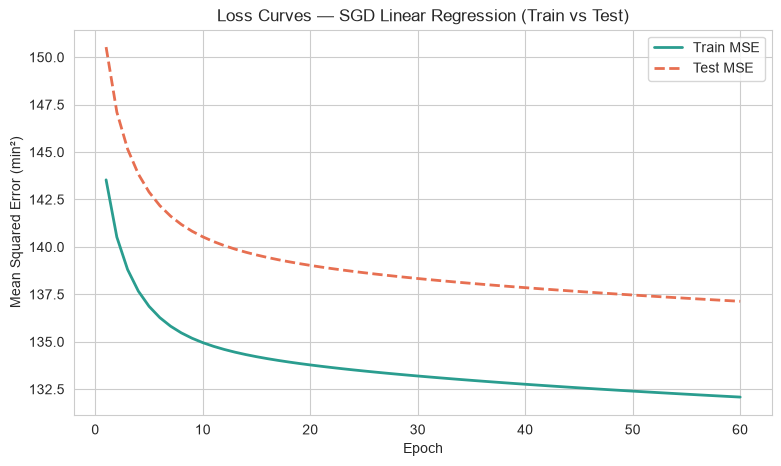

Final SGD train MSE: 132.08 | test MSE: 137.13


In [11]:
# Train the SGD model epoch by epoch with partial_fit to record train/test loss curves
n_epochs = 60
sgd = SGDRegressor(learning_rate="invscaling", eta0=0.01, penalty="l2",
                   alpha=1e-4, random_state=RANDOM_STATE)

train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

plt.figure(figsize=(9, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label="Train MSE", color="#2a9d8f", lw=2)
plt.plot(range(1, n_epochs + 1), test_losses, label="Test MSE", color="#e76f51", lw=2, ls="--")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (min²)")
plt.title("Loss Curves — SGD Linear Regression (Train vs Test)")
plt.legend()
plt.show()

print(f"Final SGD train MSE: {train_losses[-1]:.2f} | test MSE: {test_losses[-1]:.2f}")

**Interpretation:**

both curves drop steeply and flatten together, with no gap opening between them the model converges and does not overfit (test loss tracks train loss closely).

### 5.2 The three comparison models

In [12]:
models = {
    "SGD Linear Regression (gradient descent)": sgd,
    "Linear Regression (OLS)": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=12,
                                           random_state=RANDOM_STATE, n_jobs=-1),
}

results = {}
for name, model in models.items():
    if name != "SGD Linear Regression (gradient descent)":
        model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    results[name] = {
        "Test MSE (min^2)": mean_squared_error(y_test, predictions),
        "Test RMSE (min)": mean_squared_error(y_test, predictions) ** 0.5,
        "R2": r2_score(y_test, predictions),
    }

results_df = pd.DataFrame(results).T.round(3).sort_values("Test MSE (min^2)")
results_df

,Test MSE (min^2),Test RMSE (min),R2
Random Forest,121.729,11.033,0.930
Linear Regression (OLS),128.982,11.357,0.926
SGD Linear Regression (gradient descent),137.133,11.710,0.921
Decision Tree,143.831,11.993,0.917


### 5.3 Scatter plot: the fitted linear line through the data (before vs after)

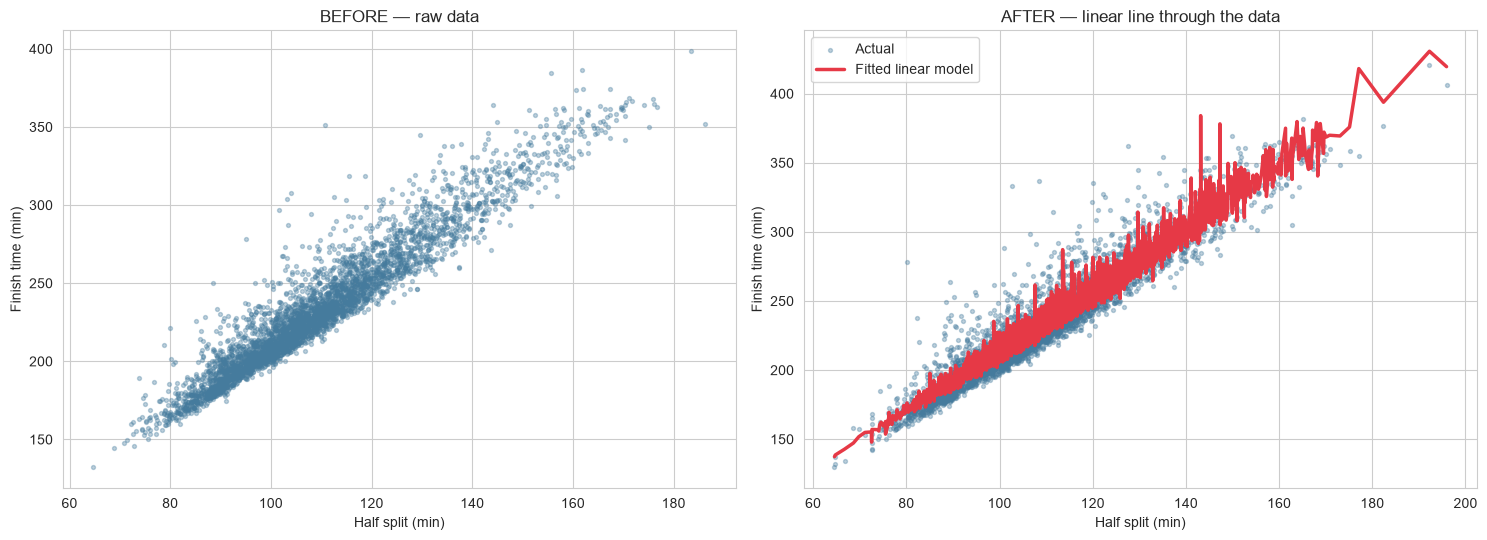

In [13]:
lr = models["Linear Regression (OLS)"]
test_sample = X_test.sample(4000, random_state=RANDOM_STATE)
test_sample_scaled = scaler.transform(test_sample)
predicted_sample = lr.predict(test_sample_scaled)

order = np.argsort(test_sample["Half_min"].values)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].scatter(sample["Half_min"], sample["Finish_min"], s=8, alpha=0.35, color="#457b9d")
axes[0].set_title("BEFORE — raw data")
axes[0].set_xlabel("Half split (min)")
axes[0].set_ylabel("Finish time (min)")

axes[1].scatter(test_sample["Half_min"], y_test.loc[test_sample.index], s=8, alpha=0.35,
                color="#457b9d", label="Actual")
axes[1].plot(test_sample["Half_min"].values[order], predicted_sample[order],
             color="#e63946", lw=2.5, label="Fitted linear model")
axes[1].set_title("AFTER — linear line through the data")
axes[1].set_xlabel("Half split (min)")
axes[1].set_ylabel("Finish time (min)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Model Selection Criteria & Saving the Best Model

**Criteria:** the best model is the one with the lowest **test MSE** (the loss metric), with test R² as a sanity check. Evaluation is on the test set so the winner is the model that generalizes, not the one that memorizes.

Random Forest wins (121.7 MSE vs 129.0 for OLS) because it captures mild non-linearities notably the "second-half fade", where runners who start too fast slow disproportionately that a straight line cannot. The small margin confirms the relationship is mostly linear, but for talent identification every minute of accuracy matters, so the model with the least loss is deployed.

In [14]:
best_name = results_df.index[0]
best_model = models[best_name]
print(f"Best model: {best_name}")

joblib.dump(best_model, "best_model.pkl", compress=3)
joblib.dump(scaler, "scaler.pkl")
joblib.dump(FEATURES, "feature_order.pkl")
print("Saved: best_model.pkl, scaler.pkl, feature_order.pkl")

Best model: Random Forest
Saved: best_model.pkl, scaler.pkl, feature_order.pkl


## 7. Prediction on One Row of the Test Set

The function below is the exact prediction logic reused by the API in Task 2.

In [15]:
def predict_finish_time(age, gender, k5, k10, k15, k20, half):
    """Predict marathon finish time (minutes) from runner profile and first-half splits."""
    model = joblib.load("best_model.pkl")
    fitted_scaler = joblib.load("scaler.pkl")
    gender_encoded = 1 if str(gender).upper() == "M" else 0
    row = pd.DataFrame([[age, gender_encoded, k5, k10, k15, k20, half]], columns=FEATURES)
    return float(model.predict(fitted_scaler.transform(row))[0])

# Prediction on one data point from the test set
one_row = X_test.iloc[[0]]
actual = y_test.iloc[0]
predicted = best_model.predict(scaler.transform(one_row))[0]

print("Input row:")
print(one_row.to_string(index=False))
print(f"\nActual finish:    {actual:.1f} min")
print(f"Predicted finish: {predicted:.1f} min")
print(f"Error: {abs(actual - predicted):.1f} minutes")

Input row:
 Age  Gender_encoded    5K_min   10K_min  15K_min  20K_min  Half_min
  50               1 19.466667 38.233333     57.5     76.9 81.083333

Actual finish:    167.8 min
Predicted finish: 166.9 min
Error: 0.9 minutes
